# 🍳 What Can I Cook Tonight? — Bayesian LDA Recipe Recommender

Given the ingredients on hand, return the Top-N recipes you can make, ranked by a composite score
that fuses **coverage**, **latent-flavor alignment**, and a **Bayesian-smoothed rating** — with
uncertainty propagated to the ranking. This notebook walks the **model-construction flow** end to end:

1. **`train_lda`** — LDA topic model: sklearn **point estimate** of φ on the **full corpus** +
   **Bootstrap** pseudo-posterior; K by held-out perplexity
2. **`filter_candidates`** — keep recipes you can actually make (ingredient coverage)
3. **`infer_user_posterior`** — Bayesian posterior over flavor topics for an ingredient set
4. **`score_recipes`** — composite score using the full (Bootstrap) φ posterior
5. **`recommend`** — Top-N recipes

> The model is **already trained and cached** in `models/lda_model.pkl`. This notebook **loads** it
> (fast); the training cell shows exactly how it was produced.

## 0 · Setup

The first cell points the working directory at the `model/` root and puts `src/` on the path, so
`import recipe_recommender` and the `data/ models/ figures/` paths resolve.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":     # launched from model/notebooks/
    os.chdir("..")                                   # -> model/
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

import recipe_recommender as rr      # the model + 5 pipeline functions  (src/)
import visualize as viz              # plotting helpers (save PNGs we then display)

pd.set_option("display.max_colwidth", 55)
df = pd.read_csv("../data/recipes_clean.csv")
print(f"{len(df):,} recipes loaded")
df.head(3)

53,573 recipes loaded


,recipe_id,recipe_name,ingredients,avg_rating,n_ratings
0,75452,beat this banana bread,"[""sugar"", ""unsalted butter"", ""banana"", ""egg"", ""lemo...",4.4,5
1,42198,better than sex strawberries,"[""vanilla wafer"", ""butter"", ""powdered sugar"", ""egg""...",3.8,5
2,67547,better then bush s baked beans,"[""great northern bean"", ""chicken bouillon cube"", ""d...",3.9,10


## 1 · The data

Food.com recipes cleaned by `src/prepare_data.py` (≥ 5 ratings, 2–35 ingredients, ingredient
names normalized). Columns: `recipe_id, recipe_name, ingredients` (JSON list), `avg_rating,
n_ratings`. Ingredient names are already canonicalized, so the coverage set-intersections in
Step 2 are meaningful.

In [2]:
ex = df.iloc[0]
print("recipe     :", ex["recipe_name"])
print("ingredients:", json.loads(ex["ingredients"]))
df[["avg_rating", "n_ratings"]].describe().round(2)

recipe     : beat this  banana bread
ingredients: ['sugar', 'unsalted butter', 'banana', 'egg', 'lemon juice', 'orange rind', 'cake flour', 'baking soda', 'salt']


,avg_rating,n_ratings
count,53573.00,53573.00
mean,4.45,15.14
std,0.53,34.48
min,0.00,5.00
25%,4.20,6.00
50%,4.58,8.00
75%,4.83,14.00
max,5.00,1613.00


## 2 · The model — sklearn point estimate of φ + Bootstrap pseudo-posterior

Classic LDA places a Dirichlet prior on the topic→ingredient distributions φ and the
recipe→topic mixtures θ. A *fully-Bayesian* posterior over φ (via NUTS) does not scale past a few
hundred recipes, so we **fit φ as a point estimate** on the **full 53k-recipe corpus** with
sklearn, and approximate φ's uncertainty by **Bootstrap**:

- **Point estimate** `φ̂` = row-normalized `LatentDirichletAllocation.components_`.
- **Bootstrap pseudo-posterior**: refit `B=50` times on resampled recipes (m-out-of-n, warm-started
  from `φ̂`); the aligned fits are kept as `phi_samples`.
- **Label alignment**: each refit's topics are permuted back onto `φ̂` with the Hungarian algorithm
  on cosine similarity (`topic_alignment.align_phi`), so `phi_samples[:, k, :]` is a coherent topic k.

**Where the Bayesian content lives.** Every downstream quantity is computed *per φ-sample then
averaged*, and the genuinely uncertain, fully-Bayesian quantity is the **user's topic posterior**
(Step 3): Bayes' theorem applied to a handful of ingredients. φ itself is a point estimate, so its
Bootstrap spread is small on a large corpus — we call it *bootstrap stability*, not a posterior.

```python
model = rr.train_lda(df)                  # K=None -> auto-select by held-out perplexity
# phi_hat = sklearn LDA on the full corpus;  phi_samples = B aligned Bootstrap refits
```

## 3 · Step 1 — `train_lda`: fit + choose K

`K` is chosen by **held-out perplexity** (train on 90% of recipes, score the held-out 10%; lower =
better). Below we **load the cached model**; the `else` branch shows how it was trained.

In [3]:
if os.path.exists("models/lda_model.pkl"):
    model = rr.load_model("models/lda_model.pkl")     # the already-trained model
    print("Loaded cached model. K =", model.best_k)
else:
    model = rr.train_lda(df)                            # sklearn fit + Bootstrap
    rr.save_model(model, "models/lda_model.pkl")

rr._STATE = {"model": model, "df_id": id(df)}          # let recommend() reuse it
print("vocab size           :", len(model.vocab))
print("Bootstrap samples (B):", model.n_samples)
print("bootstrap_stability  :", round(float(model.bootstrap_stability), 5),
      "(mean per-element φ std; small => φ well determined)")

Loaded cached model. K = 4
vocab size           : 500
Bootstrap samples (B): 50
bootstrap_stability  : 0.00044 (mean per-element φ std; small => φ well determined)


In [4]:
print("Held-out perplexity by K (lower = better):")
display(model.perplexity_table.round(1) if len(model.perplexity_table)
        else "trained with a fixed K (no sweep)")
print("\nFlavor topics:")
for k, lab in enumerate(model.topic_labels):
    print(f"  topic {k}: {lab:<40s} P(topic)={model.topic_prior[k]:.3f}")

Held-out perplexity by K (lower = better):


,K,holdout_perplexity
0,4,289.0
1,6,322.2
2,8,364.1
3,10,402.9
4,12,447.0



Flavor topics:
  topic 0: cheddar cheese / onion / green onion     P(topic)=0.189
  topic 1: olive oil / salt / parmesan cheese       P(topic)=0.246
  topic 2: salt / onion / water                     P(topic)=0.228
  topic 3: egg / salt / flour                       P(topic)=0.338


### Why K is what it is

Held-out perplexity is **monotone in K** on this corpus — it favors the smallest candidate (`K=4`),
i.e. the data genuinely supports few, coarse flavor topics. `K` is overridable
(`rr.train_lda(df, K=6)`) for richer `flavor_tags`; the recommendations are robust to `K` because
coverage and rating dominate the score.

wrote

 figures/fig1_model_selection.png


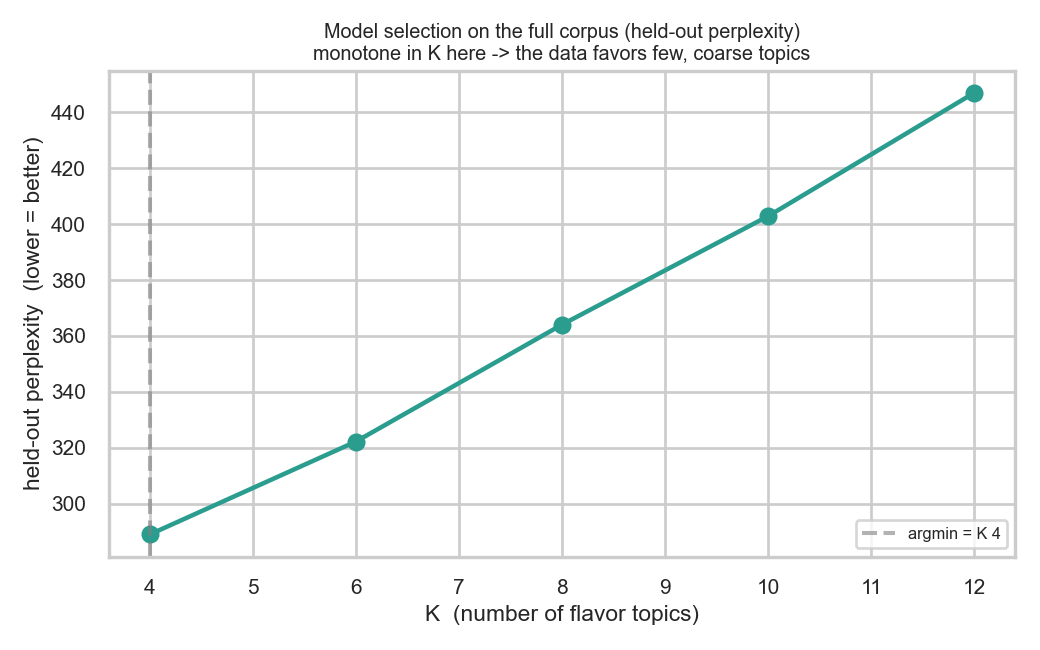

In [5]:
viz.fig_model_selection("figures/fig1_model_selection.png")
Image("figures/fig1_model_selection.png")

## 4 · The fitted topics — φ point estimate with a Bootstrap band

Each topic's top ingredients with **94% Bootstrap intervals** on `φ = P(ingredient | topic)`. The
band is small: φ is well determined on the full corpus (the honest face of the point-estimate trade).

wrote figures/fig2_topic_phi_posterior.png


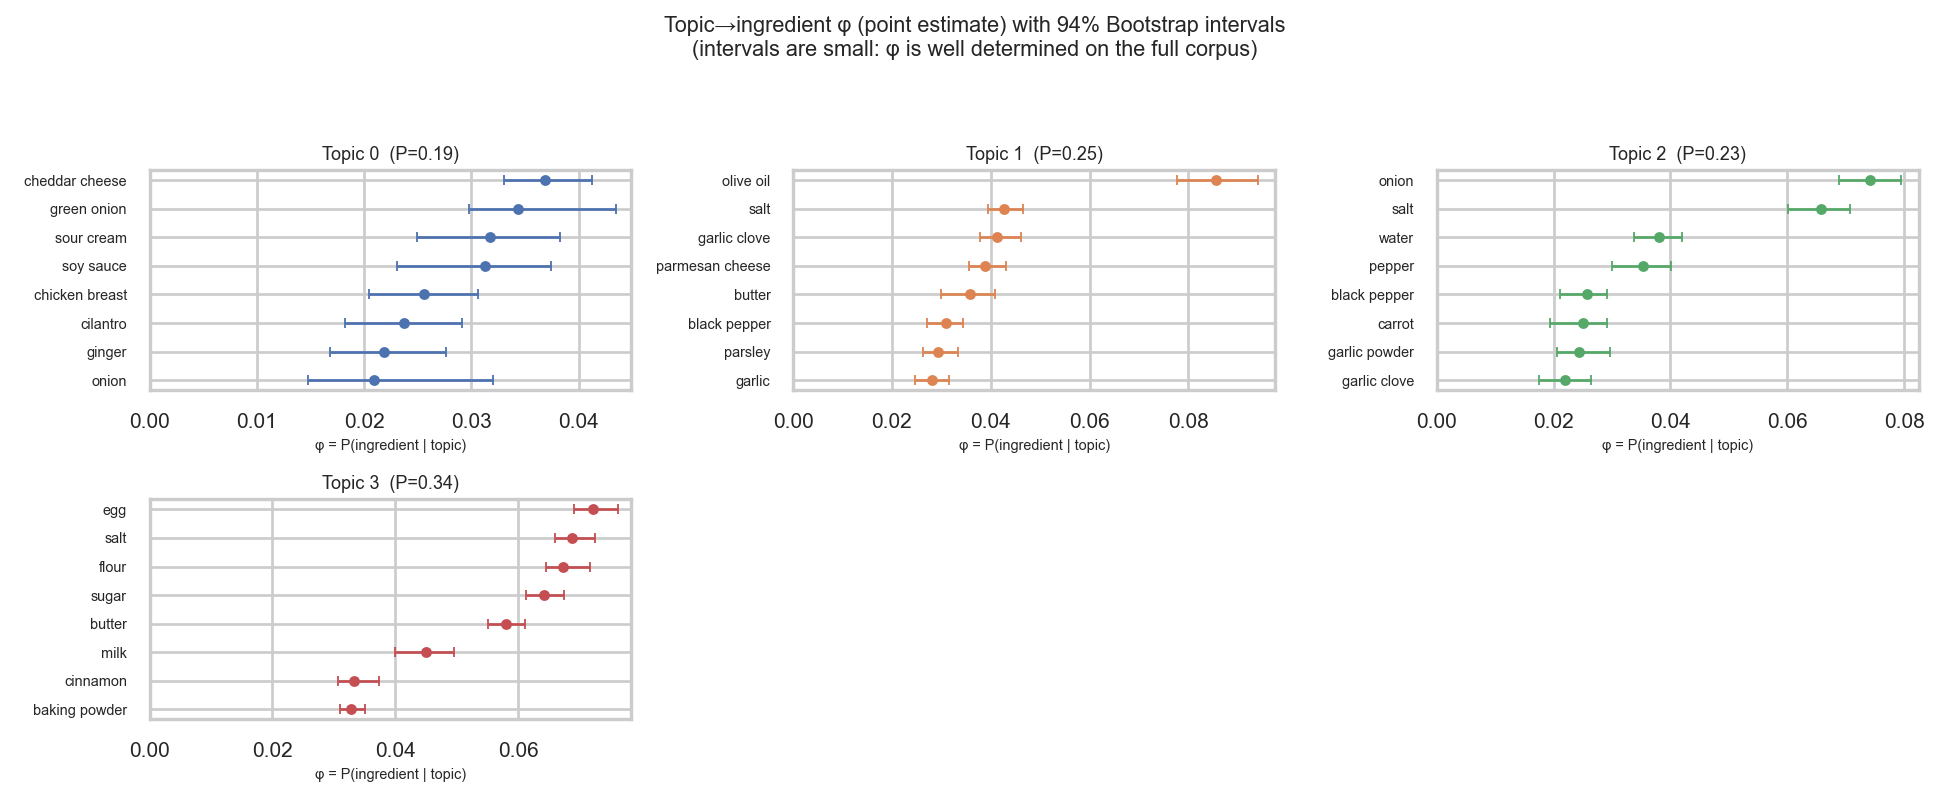

In [6]:
viz.fig_topic_phi("figures/fig2_topic_phi_posterior.png")
Image("figures/fig2_topic_phi_posterior.png")

## 5 · Steps 2–5 — the recommendation pipeline

- **`filter_candidates`** — coverage = |U ∩ R| / |R|, keep ≥ 0.7 (relax to 0.5).
- **`infer_user_posterior`** — Bayes *per φ-sample*: P(k | ingr) ∝ (∏ᵢ φ[k,i]) · P(k).
- **`score_recipes`** — coverage² · overlap_bonus · alignment · rating; alignment + uncertainty
  from the Bootstrap posterior.
- **`recommend`** — Top-N.

In [7]:
ITAL = ["chicken", "garlic", "onion", "olive oil", "tomato", "basil",
        "parmesan cheese", "pasta", "salt", "pepper"]
cols = ["recipe_name", "score", "coverage", "predicted_rating", "posterior_uncertainty"]
pd.DataFrame(rr.recommend(ITAL, df))[cols]

[filter_candidates] threshold=0.7: 53 candidate recipes


,recipe_name,score,coverage,predicted_rating,posterior_uncertainty
0,tomato sandwich from italy,2.7412,6/7 ingredients,4.803,0.0
1,garlicky tomato bruschetta,2.2959,5/6 ingredients,4.634,0.0
2,pasta with oil and garlic sauce,2.2914,5/6 ingredients,4.625,0.0
3,baked parmesan tomatoes,2.2415,5/6 ingredients,4.524,0.0
4,fresh mozzarella tomato basil salad,2.2371,5/6 ingredients,4.515,0.0


### Step 3 — the user's flavor posterior

`P(topic | pantry)` is the genuinely Bayesian step: a focused pantry collapses onto one topic
(certain), an ambiguous one spreads across two. Error bars (across Bootstrap φ) are small because φ
is well determined.

wrote figures/fig3_user_topic_posterior.png


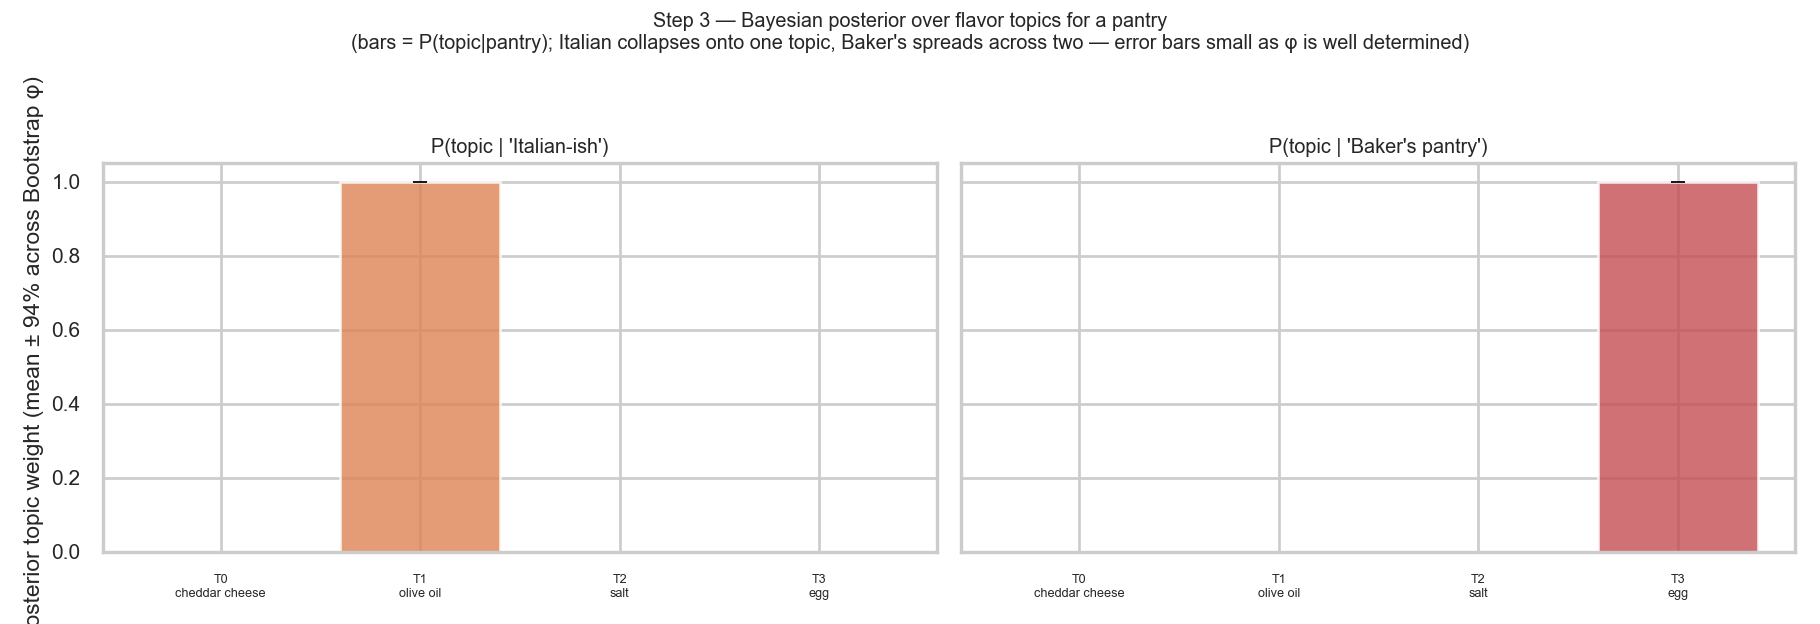

In [8]:
viz.fig_user_posterior("figures/fig3_user_topic_posterior.png")
Image("figures/fig3_user_topic_posterior.png")

### Uncertainty propagated into the ranking

Per-Bootstrap-draw flavor alignment for the Top-5 — the φ Bootstrap reaches the final score
(narrow, since φ is well determined).

[filter_candidates] threshold=0.7: 53 candidate recipes
[filter_candidates] threshold=0.7: 53 candidate recipes


wrote figures/fig4_recommendation_uncertainty.png


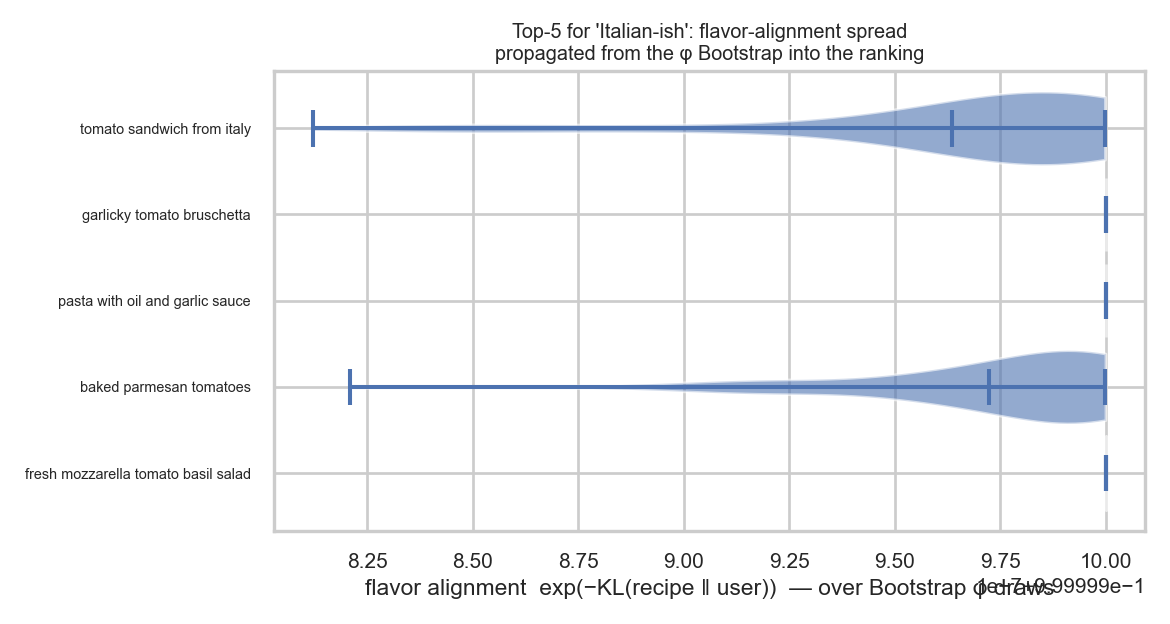

In [9]:
viz.fig_reco_uncertainty("figures/fig4_recommendation_uncertainty.png")
Image("figures/fig4_recommendation_uncertainty.png")

## 6 · User-facing options

`recommend(..., top_n=, exclude=, must_use=, diet=, diversity=)`.

In [10]:
veg = rr.recommend(ITAL, df, diet="vegetarian", must_use=["tomato"], top_n=5)
print("vegetarian + must-use tomato:")
display(pd.DataFrame(veg)[cols])

BAKE = ["flour", "sugar", "butter", "egg", "vanilla", "baking soda",
        "milk", "salt", "chocolate"]
print("diversity=0.6 (MMR re-rank for variety):")
pd.DataFrame(rr.recommend(BAKE, df, diversity=0.6, top_n=5))[cols]

[filter_candidates] threshold=0.7: 53 candidate recipes
[filters] diet=vegetarian, must_use=['tomato']: 53 -> 16 recipes
vegetarian + must-use tomato:


,recipe_name,score,coverage,predicted_rating,posterior_uncertainty
0,tomato sandwich from italy,2.7412,6/7 ingredients,4.803,0.0
1,garlicky tomato bruschetta,2.2959,5/6 ingredients,4.634,0.0
2,baked parmesan tomatoes,2.2415,5/6 ingredients,4.524,0.0
3,fresh mozzarella tomato basil salad,2.2371,5/6 ingredients,4.515,0.0
4,fresh tomato spaghetti sauce,2.0724,7/9 ingredients,4.146,0.0


diversity=0.6 (MMR re-rank for variety):
[filter_candidates] threshold=0.7: 725 candidate recipes


,recipe_name,score,coverage,predicted_rating,posterior_uncertainty
0,crustless baked custard pie,3.7250,7/7 ingredients,4.508,0.0000
1,self rising flour america,1.4369,3/4 ingredients,4.841,0.0000
2,amish friendship starter,2.5163,3/3 ingredients,4.779,0.0019
3,easy to make peanut butter cookies,1.2753,3/4 ingredients,4.297,0.0000
4,crisp butter cookies refrigerator cookies,2.3722,5/6 ingredients,4.788,0.0000


## 7 · Your final model — how to use it

The fitted model is saved in **`models/lda_model.pkl`**. To use it (from `model/`, with `src/` on
the path):

In [11]:
import sys; sys.path.insert(0, "src")
import pandas as pd, recipe_recommender as rr

df = pd.read_csv("../data/recipes_clean.csv")
model = rr.load_model("models/lda_model.pkl")     # <-- your final model
rr._STATE = {"model": model, "df_id": id(df)}     # so recommend() reuses it (no retrain)

rr.recommend(["egg", "flour", "sugar", "butter", "milk", "vanilla"], df, top_n=5)

[filter_candidates] threshold=0.7: 203 candidate recipes


[{'recipe_name': 'pancake souffle',
  'score': 3.1805,
  'coverage': '5/5 ingredients',
  'missing_ingredients': [],
  'flavor_tags': ['egg / salt / flour', 'olive oil / salt / parmesan cheese'],
  'predicted_rating': 4.458,
  'posterior_uncertainty': 0.0},
 {'recipe_name': 'portuguese queijadas',
  'score': 2.8085,
  'coverage': '5/5 ingredients',
  'missing_ingredients': [],
  'flavor_tags': ['egg / salt / flour', 'olive oil / salt / parmesan cheese'],
  'predicted_rating': 3.937,
  'posterior_uncertainty': 0.0001},
 {'recipe_name': 'german cheesecake',
  'score': 2.7487,
  'coverage': '6/7 ingredients',
  'missing_ingredients': ['cream cheese'],
  'flavor_tags': ['egg / salt / flour',
   'cheddar cheese / onion / green onion'],
  'predicted_rating': 4.816,
  'posterior_uncertainty': 0.0},
 {'recipe_name': 'pennsylvania dutch breakfast cake',
  'score': 2.6391,
  'coverage': '6/7 ingredients',
  'missing_ingredients': ['baking powder'],
  'flavor_tags': ['egg / salt / flour',
   'che

## Summary

- **Model:** LDA flavor topics — sklearn **point estimate** of φ on the **full corpus** +
  **Bootstrap** pseudo-posterior (aligned with the Hungarian matcher).
- **Selection:** held-out perplexity (monotone in K here → few, coarse topics; K overridable).
- **Bayesian where it matters:** the user's topic posterior (Step 3) is fully Bayesian and carries
  the real uncertainty; φ's Bootstrap spread is *stability* (small on a large corpus).
- **Recommender:** coverage + flavor alignment + Bayesian-smoothed rating, uncertainty propagated.
- **Artifacts:** `models/lda_model.pkl`, `results.json`, `model_selection.json`, `figures/`.
- **Reuse:** `recipe_recommender.recommend(pantry, df, ...)` — options in section 6.